## Does IS training reduce the variance of our loss estimate?

Train a **separate model for each $\alpha$** using IS-weighted loss:

$$L^{IS}(\phi) = \frac{1}{N}\sum_{i=1}^{N} w(\theta^{(i)})\,(\theta^{(i)} - f_\phi(Y^{(i)}))^2 \qquad \theta \sim q_\alpha$$

Then evaluate each model $K$ times (drawing fresh batches from its own proposal) to measure $\text{Var}(\hat{L})$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Configuration
A = 5.0
T = 64
ALPHA_VALUES = [1.2, 1.1, 1.0, 0.9, 0.8, 0.7, 0.6, 0.5,0.4,0.3]
BETA_SIGMA = 1

# Training (CPU-friendly)
N_EPOCHS = 128 # 16
N_BATCHES = 128
BATCH_SIZE = 128

# Variance experiment
K = 2000   # independent loss estimates per model
N = 128   # samples per estimate

In [3]:
def sample_from_proposal(batch_size, alpha_rho, alpha_sigma, beta_sigma, A, device='cpu'):
    rho_tilde = np.random.beta(alpha_rho, alpha_rho, size=batch_size)
    sigma_tilde = np.random.beta(alpha_sigma, beta_sigma, size=batch_size)
    rho = torch.tensor(2 * rho_tilde - 1, dtype=torch.float32, device=device)
    sigma = torch.tensor(A * sigma_tilde, dtype=torch.float32, device=device)
    return rho, sigma

def compute_importance_weights(rho, sigma, alpha_rho, alpha_sigma, beta_sigma, A):
    if torch.is_tensor(rho):
        rho = rho.cpu().numpy()
        sigma = sigma.cpu().numpy()
    rho_tilde = (rho + 1) / 2
    sigma_tilde = sigma / A
    q_rho = stats.beta.pdf(rho_tilde, alpha_rho, alpha_rho) / 2
    q_sigma = stats.beta.pdf(sigma_tilde, alpha_sigma, beta_sigma) / A
    p_theta = 1.0 / (2 * A)
    return p_theta / (q_rho * q_sigma)

def simulate_ar1_batch(rho, sigma, T, batch_size, device='cpu'):
    eps = torch.randn(batch_size, T, device=device) * sigma[:, None]
    rho_safe = torch.clamp(rho, -0.9999, 0.9999)
    x0 = torch.randn(batch_size, device=device) * sigma / torch.sqrt(1 - rho_safe**2 + 1e-8)
    x = torch.zeros(batch_size, T, device=device)
    x[:, 0] = rho * x0 + eps[:, 0]
    for t in range(1, T):
        x[:, t] = rho * x[:, t-1] + eps[:, t]
    return x

class GRUPosteriorEstimator(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, mlp_hidden=128):
        super().__init__()
        self.gru = nn.GRU(input_size=input_dim, hidden_size=hidden_dim,
                          num_layers=num_layers, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, 32), nn.ReLU(),
            nn.Linear(32, 2))
    def forward(self, x):
        x = x.unsqueeze(-1)
        gru_out, _ = self.gru(x)
        pooled = gru_out.mean(dim=1)
        raw = self.mlp(pooled)
        rho = torch.tanh(raw[:, 0])
        sigma = torch.exp(raw[:, 1])
        return torch.stack([rho, sigma], dim=1)

print("Functions loaded!")

Functions loaded!


In [4]:
# Train one model per alpha using IS-weighted loss
np.random.seed(2)
torch.manual_seed(2)

models = {}

for alpha in ALPHA_VALUES:
    print(f"\nTraining model for alpha={alpha}...")
    model = GRUPosteriorEstimator().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

    for epoch in range(N_EPOCHS):
        model.train()
        for _ in range(N_BATCHES):
            rho, sigma = sample_from_proposal(BATCH_SIZE, alpha, alpha, BETA_SIGMA, A, device=device)
            w = compute_importance_weights(rho, sigma, alpha, alpha, BETA_SIGMA, A)
            w = torch.tensor(w, dtype=torch.float32, device=device)

            x = simulate_ar1_batch(rho, sigma, T, BATCH_SIZE, device=device)
            if torch.isnan(x).any(): continue

            pred = model(x)
            per_sample_loss = ((pred - torch.stack([rho, sigma], dim=1))**2).sum(dim=1)
            loss = (w * per_sample_loss).mean()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        if (epoch + 1) % 16 == 0:
            print(f"  Epoch {epoch+1}/{N_EPOCHS}, loss = {loss.item():.4f}")

    model.eval()
    models[alpha] = model

print("\nAll models trained!")


Training model for alpha=1.2...
  Epoch 16/128, loss = 0.1361
  Epoch 32/128, loss = 0.0748
  Epoch 48/128, loss = 0.1161
  Epoch 64/128, loss = 0.1063
  Epoch 80/128, loss = 0.1023
  Epoch 96/128, loss = 0.0673
  Epoch 112/128, loss = 0.0782
  Epoch 128/128, loss = 0.0555

Training model for alpha=1.1...
  Epoch 16/128, loss = 0.1500
  Epoch 32/128, loss = 0.0878
  Epoch 48/128, loss = 0.0917
  Epoch 64/128, loss = 0.0696
  Epoch 80/128, loss = 0.0844
  Epoch 96/128, loss = 0.0701
  Epoch 112/128, loss = 0.0627
  Epoch 128/128, loss = 0.0640

Training model for alpha=1.0...
  Epoch 16/128, loss = 0.1413
  Epoch 32/128, loss = 0.0834
  Epoch 48/128, loss = 0.0998
  Epoch 64/128, loss = 0.0850
  Epoch 80/128, loss = 0.0822
  Epoch 96/128, loss = 0.0731
  Epoch 112/128, loss = 0.0763
  Epoch 128/128, loss = 0.0539

Training model for alpha=0.9...
  Epoch 16/128, loss = 0.0988
  Epoch 32/128, loss = 0.1030
  Epoch 48/128, loss = 0.0653
  Epoch 64/128, loss = 0.0769
  Epoch 80/128, loss =

In [5]:
# Evaluate each model K times using its own proposal
np.random.seed(20)

loss_estimates = {}

for alpha in ALPHA_VALUES:
    model = models[alpha]
    estimates = []
    for k in range(K):
        rho, sigma = sample_from_proposal(N, alpha, alpha, BETA_SIGMA, A, device=device)
        w = compute_importance_weights(rho, sigma, alpha, alpha, BETA_SIGMA, A)
        w = torch.tensor(w, dtype=torch.float32, device=device)

        x = simulate_ar1_batch(rho, sigma, T, N, device=device)
        with torch.no_grad():
            pred = model(x)
        per_sample_loss = ((pred - torch.stack([rho, sigma], dim=1))**2).sum(dim=1)

        estimates.append((w * per_sample_loss).mean().item())

    loss_estimates[alpha] = np.array(estimates)

# Print results
mc_var = loss_estimates[1.0].var()
print(f"{'Alpha':<10} {'Mean':<12} {'Std':<12} {'Var Ratio':<12}")
print("-"*46)
for alpha in ALPHA_VALUES:
    est = loss_estimates[alpha]
    ratio = est.var() / mc_var
    print(f"a={alpha:<8} {est.mean():<12.4f} {est.std():<12.4f} {ratio:<12.2f}")

Alpha      Mean         Std          Var Ratio   
----------------------------------------------
a=1.2      0.0745       0.0198       2.81        
a=1.1      0.0737       0.0127       1.15        
a=1.0      0.0743       0.0118       1.00        
a=0.9      0.0736       0.0110       0.87        
a=0.8      0.0758       0.0127       1.15        
a=0.7      0.0760       0.0124       1.09        
a=0.6      0.0769       0.0153       1.66        
a=0.5      0.0705       0.0156       1.74        
a=0.4      0.0786       0.0196       2.75        
a=0.3      0.0918       0.0287       5.86        


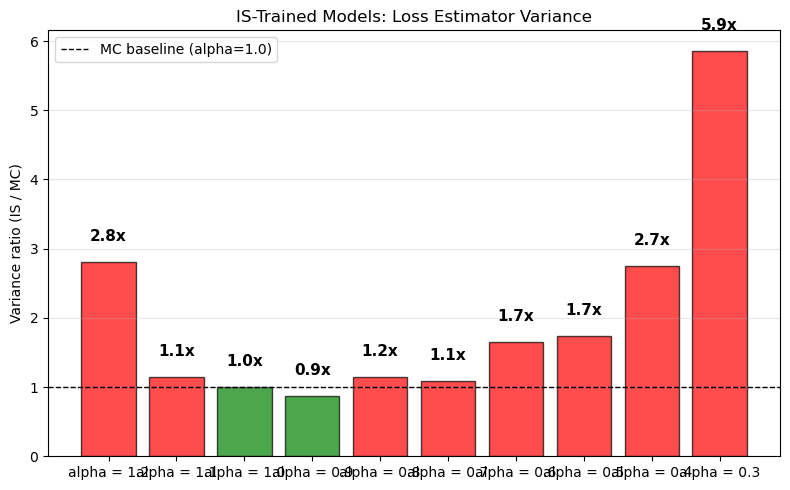

In [6]:
# Variance ratio bar chart
variances = [loss_estimates[a].var() for a in ALPHA_VALUES]
mc_var = loss_estimates[1.0].var()
ratios = [v / mc_var for v in variances]

colors = ['green' if r <= 1.0 else 'red' for r in ratios]
x_pos = np.arange(len(ALPHA_VALUES))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(x_pos, ratios, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='MC baseline (alpha=1.0)')

for bar, r in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{r:.1f}x', ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels([f'alpha = {a}' for a in ALPHA_VALUES])
ax.set_ylabel('Variance ratio (IS / MC)')
ax.set_title('IS-Trained Models: Loss Estimator Variance')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

evaluate on straight uniform data, rather than their own proposals

Alpha      Mean         Std          Var Ratio   
----------------------------------------------
a=1.2      0.0742       0.0130       1.34        
a=1.1      0.0737       0.0116       1.07        
a=1.0      0.0740       0.0113       1.00        
a=0.9      0.0738       0.0104       0.85        
a=0.8      0.0754       0.0125       1.24        
a=0.7      0.0757       0.0109       0.94        
a=0.6      0.0769       0.0118       1.11        
a=0.5      0.0707       0.0102       0.83        
a=0.4      0.0779       0.0111       0.98        
a=0.3      0.0905       0.0120       1.14        


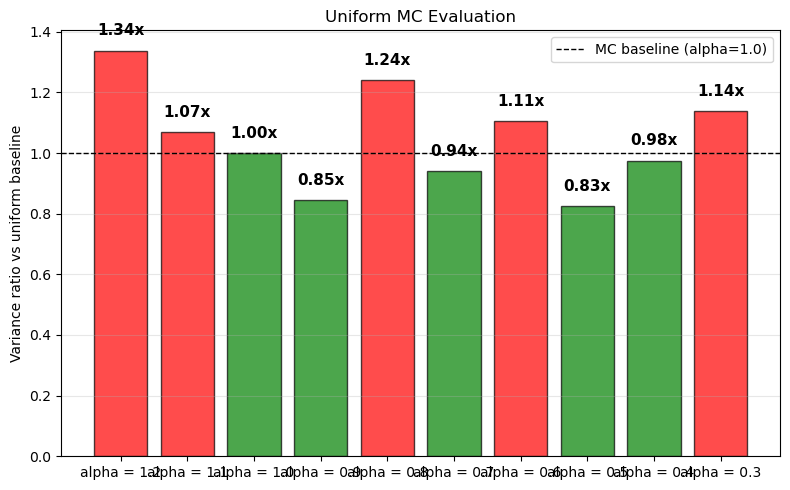

In [7]:
np.random.seed(99)
mc_estimates = {}
for alpha in ALPHA_VALUES:
    model = models[alpha]
    estimates = []
    for k in range(K):
        rho = torch.empty(N, device=device).uniform_(-1, 1)
        sigma = torch.empty(N, device=device).uniform_(0, A)

        x = simulate_ar1_batch(rho, sigma, T, N, device=device)
        with torch.no_grad():
            pred = model(x)
        per_sample_loss = ((pred - torch.stack([rho, sigma], dim=1))**2).sum(dim=1)

        estimates.append(per_sample_loss.mean().item())

    mc_estimates[alpha] = np.array(estimates)

# Print results
mc_var = mc_estimates[1.0].var()
print(f"{'Alpha':<10} {'Mean':<12} {'Std':<12} {'Var Ratio':<12}")
print("-"*46)
for alpha in ALPHA_VALUES:
    est = mc_estimates[alpha]
    ratio = est.var() / mc_var
    print(f"a={alpha:<8} {est.mean():<12.4f} {est.std():<12.4f} {ratio:<12.2f}")

# Bar chart
variances = [mc_estimates[a].var() for a in ALPHA_VALUES]
ratios = [v / mc_var for v in variances]
colors = ['green' if r <= 1.0 else 'red' for r in ratios]
x_pos = np.arange(len(ALPHA_VALUES))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(x_pos, ratios, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='MC baseline (alpha=1.0)')

for bar, r in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{r:.2f}x', ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels([f'alpha = {a}' for a in ALPHA_VALUES])
ax.set_ylabel('Variance ratio vs uniform baseline')
ax.set_title('Uniform MC Evaluation')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()